In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

(X_train, y_train), (X_test, y_test) = datasets.mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train shape: (60000, 28, 28, 1)
X_test shape: (10000, 28, 28, 1)


In [6]:
cnn = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
print("Starting training...")
history = cnn.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

print("\nEvaluating on test data...")
test_loss, test_accuracy = cnn.evaluate(X_test, y_test)

print(f"\nFinal Test Accuracy: {test_accuracy * 100:.2f}%")

Starting training...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 31ms/step - accuracy: 0.8995 - loss: 0.3262 - val_accuracy: 0.9819 - val_loss: 0.0569
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 79s 30ms/step - accuracy: 0.9840 - loss: 0.0506 - val_accuracy: 0.9874 - val_loss: 0.0401
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 29ms/step - accuracy: 0.9897 - loss: 0.0325 - val_accuracy: 0.9889 - val_loss: 0.0345
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 30ms/step - accuracy: 0.9930 - loss: 0.0221 - val_accuracy: 0.9893 - val_loss: 0.0332
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 29ms/step - accuracy: 0.9949 - loss: 0.0176 - val_accuracy: 0.9915 - val_loss: 0.0268

Evaluating on test data...
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9884 - loss: 0.0368

Final Test Accuracy: 99.15%


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
Raw prediction array for the first image:
 [1.86301859e-11 9.93573973e-12 1.90786409e-08 2.04354977e-09
 1.33104335e-11 5.27517808e-13 4.51767380e-19 9.99999940e-01
 1.40428814e-12 5.17600052e-09]

The model predicts the first image is: 7


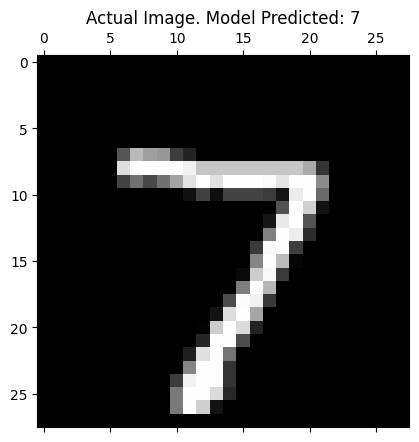

In [5]:
predictions = cnn.predict(X_test)

print(f"Raw prediction array for the first image:\n {predictions[0]}")

predicted_digit = np.argmax(predictions[0])
print(f"\nThe model predicts the first image is: {predicted_digit}")

plt.matshow(X_test[0].reshape(28,28), cmap='gray')
plt.title(f"Actual Image. Model Predicted: {predicted_digit}")
plt.show()